# Image model analysis

Load a benchmark run's best checkpoint, sample normalized autoencoder latents, decode them to images, and display an arbitrary `NROWS` by `NCOLS` grid.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from flax import nnx

working_dir = Path.cwd().resolve()
if (working_dir / "benchmark_runner.py").is_file():
    EXAMPLES_DIR = working_dir
elif (working_dir / "examples" / "benchmark_runner.py").is_file():
    EXAMPLES_DIR = working_dir / "examples"
else:
    raise FileNotFoundError("Run this notebook from the repository root or examples directory")

if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

from autoencoder_training import (
    decode_latents_to_images,
    encoder_checkpoint_dir,
    load_autoencoder,
    plot_image_grid,
)
from benchmark_runner import load_entry_model, load_experiment_entries

## Configuration

Set `SESSION_DIR` to a benchmark session containing `runs/`. Set `RUN_ID` to a specific successful run, or leave it as `None` to select the run with the lowest saved test NLL. Relative session paths are resolved from `examples/`.

In [45]:
SESSION_DIR = Path("./results/mnist_ae_64_swish_1024_x2/benchmark_20260727_162119/")
RUN_ID = "run_0006"  # For example: "run_0000"
NROWS = 6
NCOLS = 6
SEED = 2

# Override this when encoder_path in the saved config was relative to another directory.
AUTOENCODER_DIR = None
OUTPUT_PATH = None  # For example: Path("generated_images.pdf")


if AUTOENCODER_DIR is not None:
    AUTOENCODER_DIR = Path(AUTOENCODER_DIR).expanduser().resolve()
if OUTPUT_PATH is not None:
    OUTPUT_PATH = Path(OUTPUT_PATH).expanduser().resolve()

## Load and select a run

For image benchmarks, `checkpoints/best` is selected during training by minimum test NLL at evaluation time. The table below lists the successful entries available in the session.

In [46]:
entries = load_experiment_entries(SESSION_DIR)
if not entries:
    raise ValueError(f"No successful benchmark entries found in {SESSION_DIR}")

for candidate in entries:
    print(
        candidate["run_id"],
        "best_test_nll=", candidate.get("best_test_nll"),
        "method=", candidate.get("method_name", candidate.get("method")),
    )

run_0000 best_test_nll= -166.0171809217453 method= ngd
run_0001 best_test_nll= -148.44934910049437 method= ngd
run_0002 best_test_nll= inf method= ngd
run_0003 best_test_nll= inf method= ngd
run_0004 best_test_nll= inf method= ngd
run_0005 best_test_nll= inf method= ngd
run_0006 best_test_nll= -146.75163050117493 method= ngd
run_0007 best_test_nll= -150.79775778884888 method= ngd
run_0008 best_test_nll= -145.94836916866302 method= ngd
run_0009 best_test_nll= -152.6780494377136 method= ngd
run_0010 best_test_nll= -145.98722864093781 method= ngd
run_0011 best_test_nll= -151.59948679761888 method= ngd
run_0018 best_test_nll= inf method= ngd
run_0019 best_test_nll= inf method= ngd
run_0020 best_test_nll= inf method= ngd
run_0021 best_test_nll= inf method= ngd
run_0022 best_test_nll= inf method= ngd
run_0023 best_test_nll= inf method= ngd


In [47]:
if RUN_ID is None:
    entries_with_test_nll = [
        candidate for candidate in entries
        if candidate.get("best_test_nll") is not None
    ]
    if not entries_with_test_nll:
        raise ValueError("No entry has best_test_nll; set RUN_ID explicitly")
    entry = min(entries_with_test_nll, key=lambda candidate: candidate["best_test_nll"])
else:
    matching_entries = [candidate for candidate in entries if candidate["run_id"] == RUN_ID]
    if len(matching_entries) != 1:
        raise ValueError(f"Expected one entry for RUN_ID={RUN_ID!r}, found {len(matching_entries)}")
    entry = matching_entries[0]

print("Selected:", entry["run_id"])
print("Best checkpoint:", entry["checkpoints"]["best"])
print("Best test NLL:", entry.get("best_test_nll"))
print("Best iteration:", entry.get("best_iteration"))

Selected: run_0006
Best checkpoint: /Home/optimier/aksenov/Documents/code/NeuRiPP/examples/results/mnist_ae_64_swish_1024_x2/benchmark_20260727_162119/runs/run_0006/checkpoints/best
Best test NLL: -146.75163050117493
Best iteration: 17891


## Restore the model and autoencoder

The model checkpoint contains normalized latent-space parameters. `load_autoencoder` also loads the saved training-latent statistics. For a legacy autoencoder directory, it computes and writes `latent_statistics.npz` automatically.

In [48]:
model = load_entry_model(entry, key="best")

rhs = entry["architecture"]["rhs"]
dataset_name = entry["problem"]["distribution"]["name"]
encoder_dim = int(rhs["encoder_dim"])

if AUTOENCODER_DIR is None:
    encoder_base = Path(rhs.get("encoder_path", "./encoder")).expanduser()
    if not encoder_base.is_absolute():
        encoder_base = (EXAMPLES_DIR / encoder_base).resolve()
    autoencoder_dir = encoder_checkpoint_dir(encoder_base, dataset_name, encoder_dim)
else:
    autoencoder_dir = AUTOENCODER_DIR

loaded_autoencoder = load_autoencoder(autoencoder_dir)
print("Autoencoder:", loaded_autoencoder.checkpoint_dir)
print("Latent mean shape:", loaded_autoencoder.latent_mean.shape)
print("Latent covariance shape:", loaded_autoencoder.latent_covariance.shape)

Autoencoder: /Home/optimier/aksenov/Documents/code/NeuRiPP/examples/encoder/mnist/dim64
Latent mean shape: (64,)
Latent covariance shape: (64, 64)


## Sample, decode, and plot

The flow samples normalized latents. `decode_latents_to_images` reverses normalization before applying the autoencoder decoder.

In [49]:
sample_count = NROWS * NCOLS
latent_samples = model.sample(sample_count, nnx.Rngs(SEED))
images = decode_latents_to_images(latent_samples, loaded_autoencoder)
print("Latents:", latent_samples.shape)
print("Images:", images.shape)

Latents: (36, 64)
Images: (36, 28, 28)


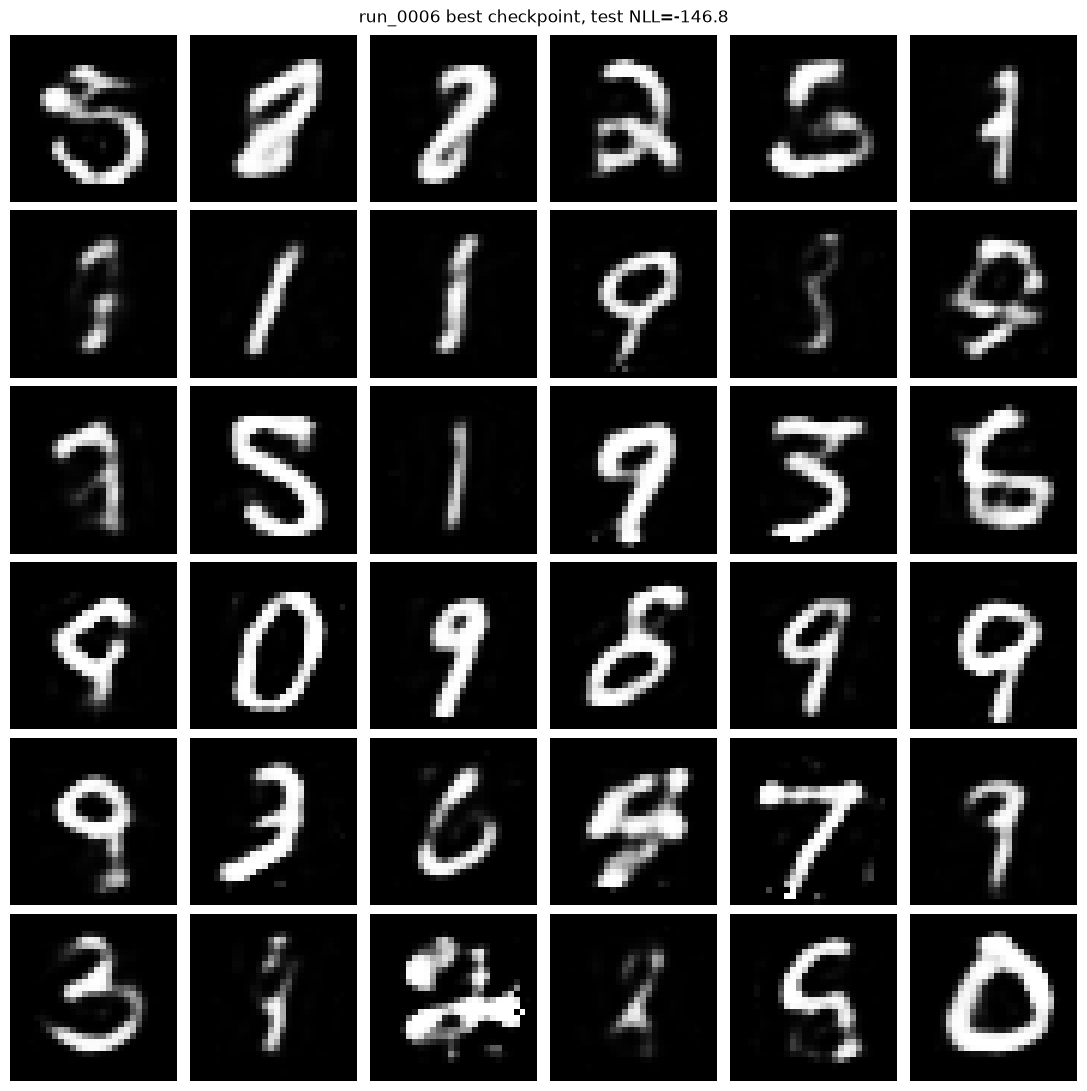

In [50]:
title = f"{entry['run_id']} best checkpoint, test NLL={entry.get('best_test_nll', float('nan')):.4g}"
fig, axes = plot_image_grid(images, NROWS, NCOLS, title=title)
if OUTPUT_PATH is not None:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_PATH)
plt.show()